## Building input pipelines in Pytorch

If the dataset is small, we can load it as tensor into memory, we can directly use this tensor for training but if the training dataset is large, we have to load them in chunks. In addition, we may have to construct a data-processing pipeline to apply any preprocessing steps.

In [30]:
import os
import numpy as np
import pathlib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
import matplotlib.pyplot as plt
from itertools import islice
from PIL import Image
import torchvision
from torchvision.transforms import transforms

If data already exist in the form of tensor, we can create a dataset loader.

In [3]:
t = torch.arange(6, dtype = torch.float32)
data_loader = DataLoader(t)

In [4]:
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


We can also create batched from this dataset.

In [ ]:
data_loader = DataLoader(t, batch_size=3, drop_last=False) #drop_last in case data size is not divisible by batch_size
for i, batch in enumerate(data_loader, start = 1):
    print(f'Batch {i}:', batch)

Batch 1: tensor([0., 1., 2.])
Batch 2: tensor([3., 4., 5.])


In [7]:
# Combining two datasets into a joint dataset
torch.manual_seed(1)
t_x = torch.rand([4,3], dtype = torch.float32)
t_y = torch.arange(4)

In [9]:
class JointDataset(Dataset):
    def __init__(self, x, y): #initial logic, reading data, filtering, etc.
        self.x = x
        self.y = y
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx): # return the corresponding sample to the given index.
        return self.x[idx], self.y[idx]

In [10]:
joint_dataset = JointDataset(t_x, t_y)

In [11]:
joint_dataset

In [12]:
for example in joint_dataset:
    print(' x: ', example[0], ' y: ', example[1])

 x:  tensor([0.7576, 0.2793, 0.4031])  y:  tensor(0)
 x:  tensor([0.7347, 0.0293, 0.7999])  y:  tensor(1)
 x:  tensor([0.3971, 0.7544, 0.5695])  y:  tensor(2)
 x:  tensor([0.4388, 0.6387, 0.5247])  y:  tensor(3)


### Shuffle, batch, repeat

In [13]:
## Shuffle the dataset
torch.manual_seed(1)
data_loader = DataLoader(dataset= joint_dataset, batch_size= 2, shuffle = True)

In [16]:
for i, batch in enumerate(data_loader, 1):
    print(f'Batch {i}:', 'x:' ,batch[0], 
          '\n       y:', batch[1])

Batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
       y: tensor([3, 2])
Batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
       y: tensor([0, 1])


The rows are shuffled without losing the one-to-one correspondence between the enteries in x and y.

When training a model for multiple epochs, we need to shuffle and iterate over the dataset by the desired number of epochs.

In [17]:
for epoch in range(2):
    print(f'epoch {epoch + 1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'Batch {i}:', 'x:' ,batch[0], 
          '\n       y:', batch[1])

epoch 1
Batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.4388, 0.6387, 0.5247]]) 
       y: tensor([0, 3])
Batch 2: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7347, 0.0293, 0.7999]]) 
       y: tensor([2, 1])
epoch 2
Batch 1: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
       y: tensor([1, 3])
Batch 2: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
       y: tensor([2, 0])


## Creating a dataset from the files on your local storage

In [2]:
imgdir_path = pathlib.Path('data/cat_dog_images')
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')]) # glob is to search for file with a specific pattern.
print(file_list)

['data/cat_dog_images/cat-01.jpg', 'data/cat_dog_images/cat-02.jpg', 'data/cat_dog_images/cat-03.jpg', 'data/cat_dog_images/dog-01.jpg', 'data/cat_dog_images/dog-02.jpg', 'data/cat_dog_images/dog-03.jpg']


Image shape: (900, 1200, 3)
Image shape: (900, 1200, 3)
Image shape: (900, 742, 3)
Image shape: (800, 1200, 3)
Image shape: (800, 1200, 3)
Image shape: (900, 1200, 3)


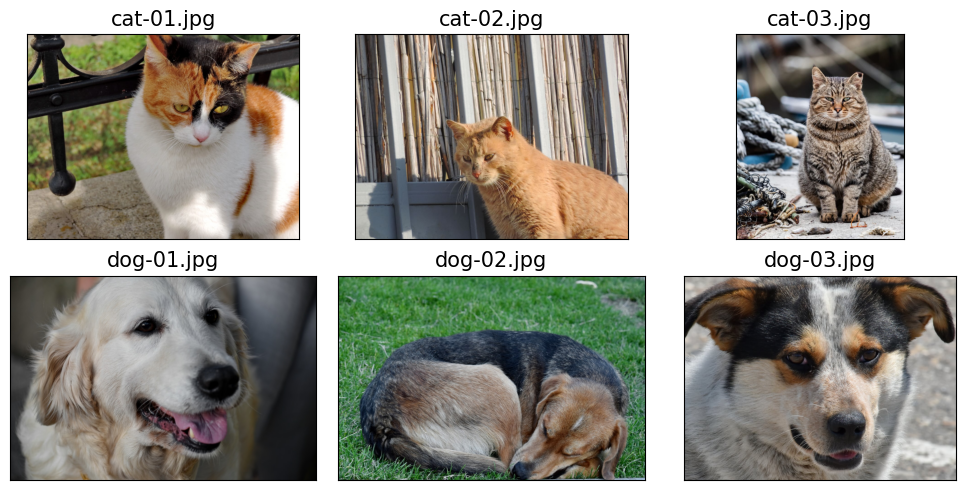

In [3]:
fig = plt.figure(figsize= (10,5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Image shape:', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size = 15)
plt.tight_layout()
plt.show()

Aspect ratio is different for each image. Some are 900 X 1200, some are 900 X 800, etc. We will preprocess the image to a consistent size.

In [4]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


Now we have 2 list, one of file name and one of label. 

In [5]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __getitem__(self, idx):
        file = self.file_list[idx]
        label = self.labels[idx]
        return file, label

    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
    print(file, label)

data/cat_dog_images/cat-01.jpg 0
data/cat_dog_images/cat-02.jpg 0
data/cat_dog_images/cat-03.jpg 0
data/cat_dog_images/dog-01.jpg 1
data/cat_dog_images/dog-02.jpg 1
data/cat_dog_images/dog-03.jpg 1


In [6]:
# transform the size of the images
img_height, img_width = 80, 120
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width))
])

In [7]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform = None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __getitem__(self, idx):
        img = Image.open(self.file_list[idx])
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels, transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000551827..1.0000002].


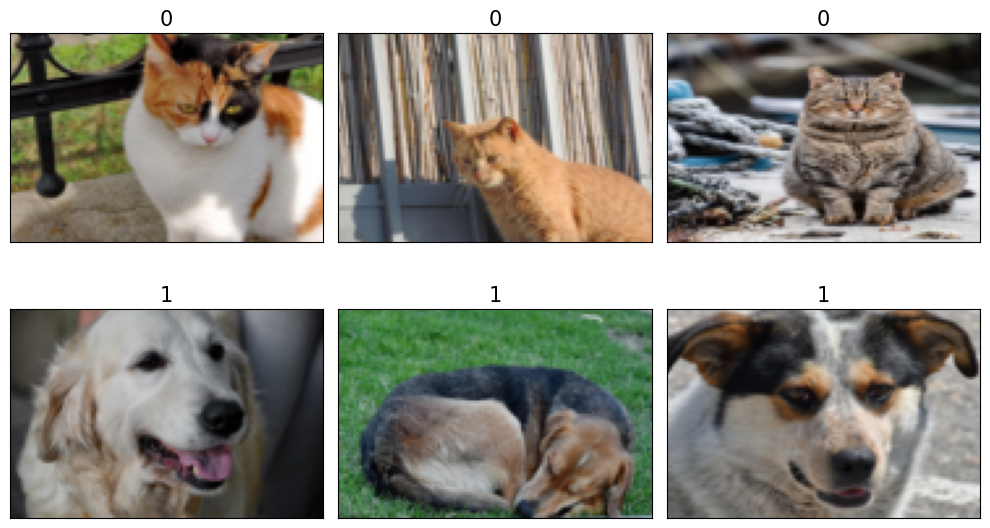

In [ ]:
fig = plt.figure(figsize= (10,6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose(1,2,0)) # convert to numpy array and reorders the dimension (C,H,W) -> (H,W,C).
    ax.set_title(f'{example[1]}', size = 15)
plt.tight_layout()
plt.show()

### Dataset available in pytorch

### 1. Celeb Dataset

In [11]:
image_path = 'data/'
celeba_dataset = torchvision.datasets.CelebA(
    image_path, split = 'train', target_type = 'attr', download = False
)

In [12]:
# To check if the object is of torch.utils.data.Dataset class.
assert isinstance(celeba_dataset, torch.utils.data.Dataset)

In [ ]:
example = next(iter(celeba_dataset))
print(example)

#The sample comes as a tuple. (PIL.Image, attributes)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x11935ECD0>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))


To have a supervised Deep learning dataset, we need to reformat it to (feature_tensor, label). 
For label, we will use smiling, which is the 31st element.

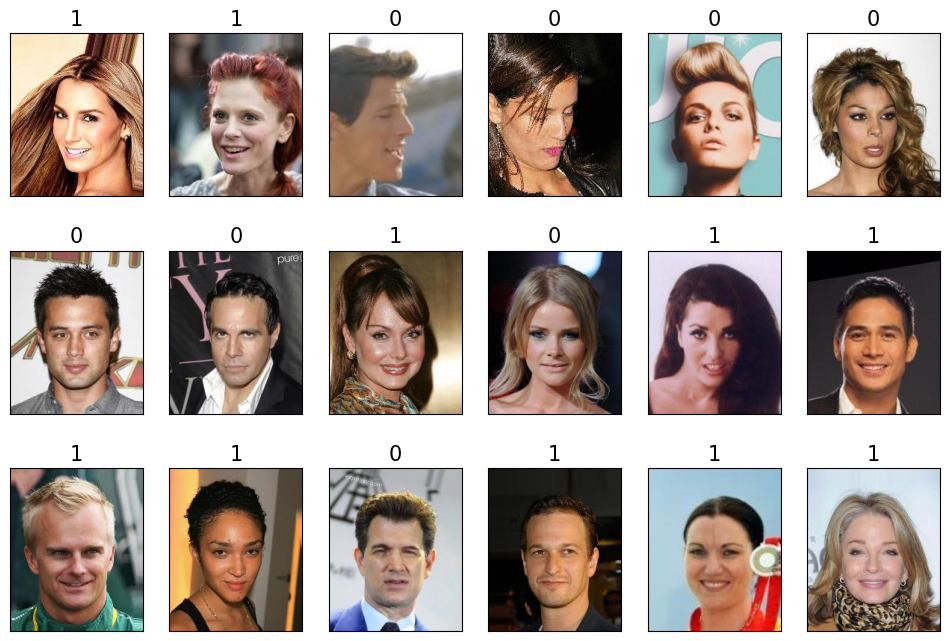

In [ ]:
fig = plt.figure(figsize= (12,8))
# used to slice iterators and generators efficiently without loading entire sequences into memory
# islice(iterable, start, stop, step)
for i, (image, attributes) in islice(enumerate(celeba_dataset), 18): 
    ax = fig.add_subplot(3, 6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image)
    ax.set_title(f'{attributes[31]}', size = 15)
plt.show()

### 2. MNIST Dataset

In [16]:
mnist_dataset = torchvision.datasets.MNIST(image_path, 'train', download = True)
assert isinstance(mnist_dataset, torch.utils.data.Dataset)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [17]:
example = next(iter(mnist_dataset))
print(example)

(<PIL.Image.Image image mode=L size=28x28 at 0x11A9F6790>, 5)


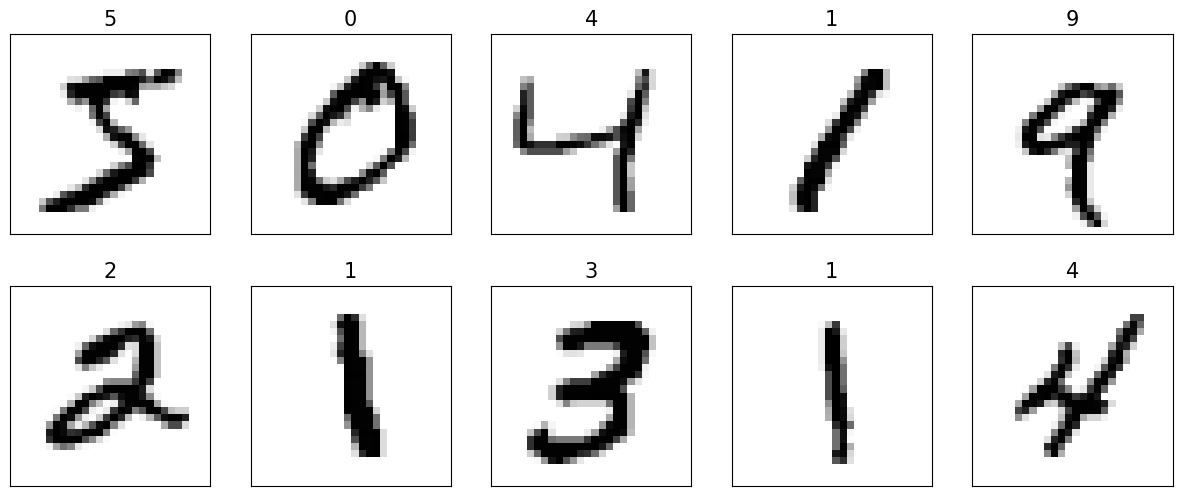

In [19]:
fig = plt.figure(figsize= (15,6))
for i, (image, label) in islice(enumerate(mnist_dataset), 10): 
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}', size = 15)
plt.show()

## Building a NN model in pytorch

### Building a linear regression model

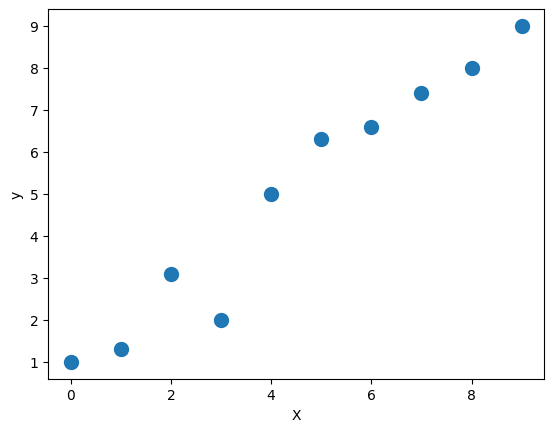

In [20]:
X_train = np.arange(10, dtype='float32').reshape((10,1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6, 7.4, 8.0, 9.0], dtype= 'float32')
plt.plot(X_train, y_train, 'o', markersize = 10)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [22]:
# standardize the data and create a pytorch dataset
X_train_norm = (X_train - np.mean(X_train))/ np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train)
train_ds = TensorDataset(X_train_norm, y_train)
batch_size = 1
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
# set weight and bias and defining model
torch.manual_seed(1)
weight = torch.randn(1)
weight.requires_grad_()
bias = torch.zeros(1, requires_grad = True)
def model(xb):
    return xb @ weight + bias

In [24]:
# defining loss function (MSE)
def loss_fn(input, target):
    return(input - target).pow(2).mean()

In [25]:
# Implement stochastic gradient method 
learning_rate = 0.001
num_epochs = 200
log_epochs = 10
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
    with torch.no_grad():
        weight -= weight.grad * learning_rate
        bias -= bias.grad * learning_rate
        weight.grad.zero_()
        bias.grad.zero_()
    if epoch % log_epochs == 0:
        print(f'Epoch {epoch} Loss {loss.item():.4f}')

Epoch 0 Loss 46.5720
Epoch 10 Loss 27.1502
Epoch 20 Loss 1.6446
Epoch 30 Loss 14.4571
Epoch 40 Loss 11.7827
Epoch 50 Loss 6.4122
Epoch 60 Loss 0.6339
Epoch 70 Loss 3.1562
Epoch 80 Loss 2.0100
Epoch 90 Loss 0.3107
Epoch 100 Loss 0.7625
Epoch 110 Loss 1.0024
Epoch 120 Loss 0.0232
Epoch 130 Loss 0.5138
Epoch 140 Loss 0.0741
Epoch 150 Loss 1.8712
Epoch 160 Loss 0.0007
Epoch 170 Loss 0.0850
Epoch 180 Loss 0.0634
Epoch 190 Loss 0.0012


In [26]:
print('Final paramters:', weight.item(), bias.item())

Final paramters: 2.670930862426758 4.88258695602417


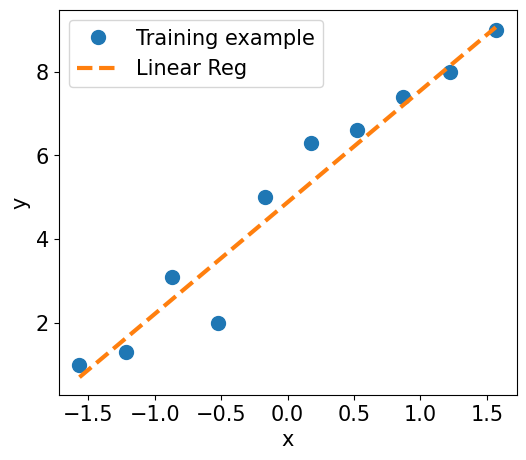

In [28]:
X_test = np.linspace(0, 9, num = 100, dtype='float32').reshape(-1,1)
X_test_norm = (X_test - np.mean(X_train))/ np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()

fig = plt.figure(figsize= (13,5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize = 10)
plt.plot(X_test_norm, y_pred, '--', lw = 3)
plt.legend(['Training example','Linear Reg'], fontsize = 15)
ax.set_xlabel('x', size = 15)
ax.set_ylabel('y', size = 15)
ax.tick_params(axis = 'both', which = 'major', labelsize = 15)
plt.show()

### Model training using torch.nn

In [31]:
loss_fn = nn.MSELoss(reduction = 'mean')
input_size = 1
output_size = 1
model = nn.Linear(input_size, output_size) # Applies an affine linear transformation to the incoming data: y = x A_t + b
optimizer = torch.optim.SGD(model.parameters(), lr= learning_rate)

In [34]:
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        #generate prediction
        pred = model(x_batch)[:, 0]
        #calculate loss
        loss = loss_fn(pred, y_batch)
        #compute gradients
        loss.backward()
        #Update parameters using gradient
        optimizer.step()
        #Reset gradients to zero
        optimizer.zero_grad()

    if epoch % log_epochs == 0:
        print(f'Epoch {epoch} Loss {loss.item():.4f}')

Epoch 0 Loss 94.0656
Epoch 10 Loss 0.4005
Epoch 20 Loss 21.6717
Epoch 30 Loss 27.2417
Epoch 40 Loss 0.0318
Epoch 50 Loss 0.1004
Epoch 60 Loss 5.6463
Epoch 70 Loss 3.8838
Epoch 80 Loss 0.0157
Epoch 90 Loss 1.5318
Epoch 100 Loss 2.5846
Epoch 110 Loss 0.4920
Epoch 120 Loss 1.8523
Epoch 130 Loss 0.4990
Epoch 140 Loss 0.3813
Epoch 150 Loss 1.9398
Epoch 160 Loss 1.1773
Epoch 170 Loss 0.4228
Epoch 180 Loss 0.0804
Epoch 190 Loss 0.1326


In [35]:
print("Final parameters: ", model.weight.item(), model.bias.item())

Final parameters:  2.6495792865753174 4.877299785614014
